In [9]:
import pandas as pd
import numpy as np
import pm4py
from pm4py.objects.log.util import sorting
from scipy.stats import wasserstein_distance
from sklearn import preprocessing

from log_distance_measures.config import EventLogIDs, AbsoluteTimestampType, discretize_to_hour
from log_distance_measures.control_flow_log_distance import control_flow_log_distance
from log_distance_measures.n_gram_distribution import n_gram_distribution_distance
from log_distance_measures.absolute_event_distribution import absolute_event_distribution_distance
from log_distance_measures.case_arrival_distribution import case_arrival_distribution_distance
from log_distance_measures.circadian_event_distribution import circadian_event_distribution_distance
from log_distance_measures.relative_event_distribution import relative_event_distribution_distance
from log_distance_measures.work_in_progress import work_in_progress_distance
from log_distance_measures.cycle_time_distribution import cycle_time_distribution_distance

import warnings
warnings.filterwarnings("ignore")

In [10]:
import re
def extract_first_float(cell):
    if isinstance(cell, str):
        # Use regular expression to extract the first float and the value in brackets
        match = re.match(r'(\d+\.\d+)(?: \((\d+\.\d+)\))?', cell)
        if match:
            return float(match.group(1)), (match.group(2)) if match.group(2) else ''
        else:
            return float('inf'), ''
    else:
        return cell, ''

In [11]:
def highlight_min_max(s):
    """
    Highlight the minimum value in green and the maximum value in red for each column.
    """
    is_min = s == s.min()
    is_max = s == s.max()
    min_max_style = ['background-color: green' if v else '' for v in is_min]
    for i, v in enumerate(is_max):
        if v:
            min_max_style[i] = 'background-color: red'
    return min_max_style

In [12]:
def align_column_names(df):
    if 'case:concept:name' in df.columns:
        df = df.rename(columns={'case:concept:name': 'case_id'})
    elif 'caseid' in df.columns:
        df = df.rename(columns={'caseid': 'case_id'})
    if 'Activity' in df.columns:
        df = df.rename(columns={'Activity': 'activity'})
    elif 'activity_name' in df.columns:
        df = df.rename(columns={'activity_name': 'activity'})
    elif 'task' in df.columns:
        df = df.rename(columns={'task': 'activity'})
    elif 'concept:name' in df.columns:
        df = df.rename(columns={'concept:name': 'activity'})
    if 'Resource' in df.columns:
        df = df.rename(columns={'Resource': 'resource'})
    elif 'user' in df.columns:
        df = df.rename(columns={'user': 'resource'})
    elif 'agent' in df.columns:
        if 'resource' in df.columns:
            df = df.drop(['resource'], axis=1)
        df = df.rename(columns={'agent': 'resource'})
    elif 'org:resource' in df.columns:
        df = df.rename(columns={'org:resource': 'resource'})
    if 'start_timestamp' in df.columns:
        df = df.rename(columns={'start_timestamp': 'start_time'})
    if 'end_timestamp' in df.columns:
        df = df.rename(columns={'end_timestamp': 'end_time'})
    # for SIMOD simulated logs
    if 'start_time' in df.columns:
        df = df.rename(columns={'start_time': 'start_time'})
    if 'end_time' in df.columns:
        df = df.rename(columns={'end_time': 'end_time'})
    if 'start:timestamp' in df.columns:
        df = df.rename(columns={'start:timestamp': 'start_time'})
    if 'time:timestamp' in df.columns:
        df = df.rename(columns={'time:timestamp': 'end_time'})
    return df

In [13]:
import numpy as np
import pandas as pd
from scipy.linalg import norm

def compute_transition_matrix(event_log: pd.DataFrame, case_id_col: str, resource_col: str) -> pd.DataFrame:
    """
    Compute the transition matrix of resources from an event log.
    
    :param event_log: Event log as a pandas DataFrame.
    :param case_id_col: Column name for case IDs in the log.
    :param resource_col: Column name for resources in the log.
    :return: A pandas DataFrame representing the transition matrix.
    """
    # Convert case IDs and resources to strings to avoid numeric index issues
    event_log = event_log.copy()
    event_log[case_id_col] = event_log[case_id_col].astype(str)
    event_log[resource_col] = event_log[resource_col].astype(str)

    # Sort events within each case by timestamp
    event_log = event_log.sort_values(by=[case_id_col, 'start_time', 'end_time']).reset_index(drop=True)
    
    # Extract transitions (resource pairs) as tuples
    transitions = []
    for _, case_events in event_log.groupby(case_id_col):
        resources = case_events[resource_col].values.tolist()
        # Only add transitions if there are at least 2 events
        if len(resources) >= 2:
            transitions.extend([(str(resources[i]), str(resources[i + 1])) 
                              for i in range(len(resources) - 1)])
    
    # If no transitions found, return empty matrix
    if not transitions:
        return pd.DataFrame()
    
    # Create transition matrix
    unique_resources = sorted(set(r for pair in transitions for r in pair))
    transition_matrix = pd.DataFrame(0, index=unique_resources, columns=unique_resources)
    
    # Count transitions
    for from_res, to_res in transitions:
        transition_matrix.loc[from_res, to_res] += 1
    
    # Normalize rows to probabilities
    row_sums = transition_matrix.sum(axis=1)
    # Avoid division by zero by replacing 0 sums with 1
    row_sums = row_sums.replace(0, 1)
    transition_matrix = transition_matrix.div(row_sums, axis=0)
    
    return transition_matrix

def transition_matrix_distance(original_log: pd.DataFrame, simulated_log: pd.DataFrame,
                               case_id_col: str, resource_col: str) -> float:
    """
    Compute the distance between resource transition matrices of two event logs.
    
    :param original_log: Original event log as a pandas DataFrame.
    :param simulated_log: Simulated event log as a pandas DataFrame.
    :param case_id_col: Column name for case IDs in the logs.
    :param resource_col: Column name for resources in the logs.
    :return: Frobenius norm of the difference between the two transition matrices.
    """
    # Compute transition matrices
    original_matrix = compute_transition_matrix(original_log, case_id_col, resource_col)
    simulated_matrix = compute_transition_matrix(simulated_log, case_id_col, resource_col)
    
    # Align matrices to have the same resources
    all_resources = sorted(set(original_matrix.index).union(set(simulated_matrix.index)))
    original_matrix = original_matrix.reindex(index=all_resources, columns=all_resources, fill_value=0)
    simulated_matrix = simulated_matrix.reindex(index=all_resources, columns=all_resources, fill_value=0)
    
    # Compute Frobenius norm of the difference
    distance = norm(original_matrix.values - simulated_matrix.values, ord='fro')
    return distance

In [14]:
def main_(log_paths, name_experiments):
    def perform_evauluation(all_metrics, PATH_SIMULATED_LOG, test_log):
        for i in range(10):
            # print(f"Evaluate simulation {i}")
            path_simulated_file = PATH_SIMULATED_LOG + '/simulated_log_' + str(i) + '.csv'
            # read simulated log and align column names
            simulated_log = pd.read_csv(path_simulated_file)
            simulated_log = align_column_names(simulated_log)
            # print(simulated_log)
            # print("########")
            # print(simulated_log[event_log_ids.activity].unique())
            simulated_log[event_log_ids.start_time] = pd.to_datetime(simulated_log[event_log_ids.start_time], utc=True, format='mixed')
            simulated_log[event_log_ids.end_time] = pd.to_datetime(simulated_log[event_log_ids.end_time], utc=True, format='mixed')

            # Call passing the event logs, and its column ID mappings
            ngd = n_gram_distribution_distance(test_log, event_log_ids, simulated_log, event_log_ids, n=3)
            all_metrics['NGD'].append(ngd)

            # Call passing the event logs, its column ID mappings, timestamp type, and discretize function
            aedd = absolute_event_distribution_distance(
                test_log, event_log_ids,  # First event log and its column id mappings
                simulated_log, event_log_ids,  # Second event log and its column id mappings
                discretize_type=AbsoluteTimestampType.BOTH,  # Type of timestamp distribution (consider start times and/or end times)
                discretize_event=discretize_to_hour  # Function to discretize the absolute seconds of each timestamp (default by hour)
            )
            all_metrics['AEDD'].append(aedd)

            # cadd = case_arrival_distribution_distance(
            #     test_log, event_log_ids,  # First event log and its column id mappings
            #     simulated_log, event_log_ids,  # Second event log and its column id mappings
            #     discretize_event=discretize_to_hour  # Function to discretize each timestamp (default by hour)
            # )
            # all_metrics['CADD'].append(cadd)

            cedd = circadian_event_distribution_distance(
                test_log, event_log_ids,  # First event log and its column id mappings
                simulated_log, event_log_ids,  # Second event log and its column id mappings
                discretize_type=AbsoluteTimestampType.BOTH  # Consider both start/end timestamps of each activity instance
            )
            all_metrics['CEDD'].append(cedd)

            redd = relative_event_distribution_distance(
                test_log, event_log_ids,  # First event log and its column id mappings
                simulated_log, event_log_ids,  # Second event log and its column id mappings
                discretize_type=AbsoluteTimestampType.BOTH,  # Type of timestamp distribution (consider start times and/or end times)
                discretize_event=discretize_to_hour  # Function to discretize the absolute seconds of each timestamp (default by hour)
            )
            all_metrics['REDD'].append(redd)


            ctdd = cycle_time_distribution_distance(
                test_log, event_log_ids,  # First event log and its column id mappings
                simulated_log, event_log_ids,  # Second event log and its column id mappings
                bin_size=pd.Timedelta(hours=1)  # Bins of 1 hour
            )
            all_metrics['CTDD'].append(ctdd)

            # rtmd = transition_matrix_distance(test_log, simulated_log, 'case_id', 'resource')
            # all_metrics['RTMD'].append(rtmd)

        return all_metrics
    
    number_evaluations = len(log_paths)

    # Set event log column ID mapping
    event_log_ids = EventLogIDs(  # These values are stored in DEFAULT_CSV_IDS
        case="case_id",
        activity="activity",
        start_time="start_time",
        end_time="end_time",
        resource='resource'
    )

    index_names = name_experiments
    results_df = pd.DataFrame(index=index_names)
    mean_results = pd.DataFrame(index=index_names)

    for experiment in range(number_evaluations):
        # Read and transform time attributes
        test_log = pd.read_csv(log_paths[experiment][0])
        test_log = align_column_names(test_log)
        test_log[event_log_ids.start_time] = pd.to_datetime(test_log[event_log_ids.start_time], utc=True, format='mixed')
        test_log[event_log_ids.end_time] = pd.to_datetime(test_log[event_log_ids.end_time], utc=True, format='mixed')

        PATH_SIMULATED_LOG = log_paths[experiment][1]

        all_metrics = {
            'NGD': [],
            'AEDD': [],
            # 'CADD': [],
            'CEDD': [],
            'REDD': [],
            'CTDD': [],
            # 'RTMD': [],
        }

        all_metrics = perform_evauluation(all_metrics, PATH_SIMULATED_LOG, test_log)

        mean_results.loc[index_names[experiment], 'N-Gram Distribution Distance'] = round(np.mean(all_metrics['NGD']), 3)
        mean_results.loc[index_names[experiment], 'Absolute Event Distribution Distance'] = round(np.mean(all_metrics['AEDD']), 3)
        # mean_results.loc[index_names[experiment], 'Case Arrival Distribution Distance'] = round(np.mean(all_metrics['CADD']), 3)
        mean_results.loc[index_names[experiment], 'Circadian Event Distribution Distance'] = round(np.mean(all_metrics['CEDD']), 3)
        mean_results.loc[index_names[experiment], 'Relative Event Distribution Distance'] = round(np.mean(all_metrics['REDD']), 3)
        mean_results.loc[index_names[experiment], 'Cycle Time Distribution Distance'] = round(np.mean(all_metrics['CTDD']), 3)
        # mean_results.loc[index_names[experiment], 'Resource Transition Matrix Distance'] = round(np.mean(all_metrics['RTMD']), 3)

    

        results_df.loc[index_names[experiment], 'N-Gram Distribution Distance'] = f"{round(np.mean(all_metrics['NGD']), 3)} ({round(np.std(all_metrics['NGD']), 3)})"
        results_df.loc[index_names[experiment], 'Absolute Event Distribution Distance'] = f"{round(np.mean(all_metrics['AEDD']), 3)} ({round(np.std(all_metrics['AEDD']), 3)})"
        # results_df.loc[index_names[experiment], 'Case Arrival Distribution Distance'] = f"{round(np.mean(all_metrics['CADD']), 3)} ({round(np.std(all_metrics['CADD']), 3)})"
        results_df.loc[index_names[experiment], 'Circadian Event Distribution Distance'] = f"{round(np.mean(all_metrics['CEDD']), 3)} ({round(np.std(all_metrics['CEDD']), 3)})"
        results_df.loc[index_names[experiment], 'Relative Event Distribution Distance'] = f"{round(np.mean(all_metrics['REDD']), 3)} ({round(np.std(all_metrics['REDD']), 3)})"
        results_df.loc[index_names[experiment], 'Cycle Time Distribution Distance'] = f"{round(np.mean(all_metrics['CTDD']), 3)} ({round(np.std(all_metrics['CTDD']), 3)})"
        # results_df.loc[index_names[experiment], 'Resource Transition Matrix Distance'] = f"{round(np.mean(all_metrics['RTMD']), 3)} ({round(np.std(all_metrics['RTMD']), 3)})"
    return mean_results, results_df


In [15]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel

# --- Your other imports and definitions (such as align_column_names, EventLogIDs, etc.) --- #

def get_rankings(metric_results, alpha=0.05):
    """
    Given a dictionary mapping experiment names to a list of metric values
    (e.g. 10 evaluations), compute a ranking (smaller is better) using paired t-tests.
    
    The procedure is as follows:
      1. Sort experiments by their mean (ascending).
      2. For each experiment (starting from the second best), compare its values 
         with each experiment that already received a rank (i.e. with a lower mean).
      3. If the paired t-test between the current experiment and any lower ranked 
         experiment returns a p-value >= alpha (i.e. the difference is not significant),
         then assign the same rank as that experiment.
      4. If the current experiment is significantly different (p < alpha) from all lower-ranked
         experiments, assign a new rank equal to (max(current ranks) + 1).
    """
    # Compute means for sorting
    means = {exp: np.mean(values) for exp, values in metric_results.items()}
    sorted_exps = sorted(means, key=lambda exp: means[exp])
    ranks = {}
    
    for i, exp in enumerate(sorted_exps):
        if i == 0:
            ranks[exp] = 1
        else:
            # Look for at least one experiment with a lower mean that is not significantly different.
            assigned_rank = None
            for lower_exp in sorted_exps[:i]:
                # Perform paired t-test between current experiment and a lower–ranked experiment.
                stat, p_val = ttest_rel(metric_results[exp], metric_results[lower_exp])
                if p_val >= alpha:
                    # Not significantly different: candidate for same rank.
                    candidate_rank = ranks[lower_exp]
                    # In case more than one lower experiment qualifies, choose the smallest rank.
                    if assigned_rank is None or candidate_rank < assigned_rank:
                        assigned_rank = candidate_rank
            if assigned_rank is None:
                # If current experiment is significantly different from every lower experiment,
                # assign a new rank.
                new_rank = max(ranks.values()) + 1
                ranks[exp] = new_rank
            else:
                ranks[exp] = assigned_rank
    return ranks


def main_(log_paths, name_experiments):
    def perform_evauluation(all_metrics, PATH_SIMULATED_LOG, test_log):
        for i in range(10):
            # Evaluate simulation i
            path_simulated_file = PATH_SIMULATED_LOG + '/simulated_log_' + str(i) + '.csv'
            simulated_log = pd.read_csv(path_simulated_file)
            simulated_log = align_column_names(simulated_log)
            simulated_log[event_log_ids.start_time] = pd.to_datetime(simulated_log[event_log_ids.start_time], utc=True, format='mixed')
            simulated_log[event_log_ids.end_time] = pd.to_datetime(simulated_log[event_log_ids.end_time], utc=True, format='mixed')
    
            # Compute metrics on the simulated log vs. the test log
            ngd = n_gram_distribution_distance(test_log, event_log_ids, simulated_log, event_log_ids, n=3)
            all_metrics['NGD'].append(ngd)
    
            aedd = absolute_event_distribution_distance(
                test_log, event_log_ids,
                simulated_log, event_log_ids,
                discretize_type=AbsoluteTimestampType.BOTH,
                discretize_event=discretize_to_hour
            )
            all_metrics['AEDD'].append(aedd)
    
            cedd = circadian_event_distribution_distance(
                test_log, event_log_ids,
                simulated_log, event_log_ids,
                discretize_type=AbsoluteTimestampType.BOTH
            )
            all_metrics['CEDD'].append(cedd)
    
            redd = relative_event_distribution_distance(
                test_log, event_log_ids,
                simulated_log, event_log_ids,
                discretize_type=AbsoluteTimestampType.BOTH,
                discretize_event=discretize_to_hour
            )
            all_metrics['REDD'].append(redd)
    
            ctdd = cycle_time_distribution_distance(
                test_log, event_log_ids,
                simulated_log, event_log_ids,
                bin_size=pd.Timedelta(hours=1)
            )
            all_metrics['CTDD'].append(ctdd)
    
        return all_metrics

    number_evaluations = len(log_paths)

    # Set event log column ID mapping
    event_log_ids = EventLogIDs(
        case="case_id",
        activity="activity",
        start_time="start_time",
        end_time="end_time",
        resource='resource'
    )

    index_names = name_experiments
    results_df = pd.DataFrame(index=index_names)
    mean_results = pd.DataFrame(index=index_names)

    # --- Prepare a dictionary to save the raw metric values (lists of 10 values) per experiment ---
    per_experiment_metrics = {
        'NGD': {},
        'AEDD': {},
        'CEDD': {},
        'REDD': {},
        'CTDD': {}
    }
    
    for experiment in range(number_evaluations):
        # Read test log and convert time attributes
        test_log = pd.read_csv(log_paths[experiment][0])
        test_log = align_column_names(test_log)
        test_log[event_log_ids.start_time] = pd.to_datetime(test_log[event_log_ids.start_time], utc=True, format='mixed')
        test_log[event_log_ids.end_time] = pd.to_datetime(test_log[event_log_ids.end_time], utc=True, format='mixed')
    
        PATH_SIMULATED_LOG = log_paths[experiment][1]
    
        all_metrics = {
            'NGD': [],
            'AEDD': [],
            'CEDD': [],
            'REDD': [],
            'CTDD': [],
        }
    
        all_metrics = perform_evauluation(all_metrics, PATH_SIMULATED_LOG, test_log)
    
        # Save mean and std values in your results DataFrames
        mean_results.loc[index_names[experiment], 'N-Gram Distribution Distance'] = round(np.mean(all_metrics['NGD']), 3)
        mean_results.loc[index_names[experiment], 'Absolute Event Distribution Distance'] = round(np.mean(all_metrics['AEDD']), 3)
        mean_results.loc[index_names[experiment], 'Circadian Event Distribution Distance'] = round(np.mean(all_metrics['CEDD']), 3)
        mean_results.loc[index_names[experiment], 'Relative Event Distribution Distance'] = round(np.mean(all_metrics['REDD']), 3)
        mean_results.loc[index_names[experiment], 'Cycle Time Distribution Distance'] = round(np.mean(all_metrics['CTDD']), 3)
    
        results_df.loc[index_names[experiment], 'N-Gram Distribution Distance'] = f"{round(np.mean(all_metrics['NGD']), 3)} ({round(np.std(all_metrics['NGD']), 3)})"
        results_df.loc[index_names[experiment], 'Absolute Event Distribution Distance'] = f"{round(np.mean(all_metrics['AEDD']), 3)} ({round(np.std(all_metrics['AEDD']), 3)})"
        results_df.loc[index_names[experiment], 'Circadian Event Distribution Distance'] = f"{round(np.mean(all_metrics['CEDD']), 3)} ({round(np.std(all_metrics['CEDD']), 3)})"
        results_df.loc[index_names[experiment], 'Relative Event Distribution Distance'] = f"{round(np.mean(all_metrics['REDD']), 3)} ({round(np.std(all_metrics['REDD']), 3)})"
        results_df.loc[index_names[experiment], 'Cycle Time Distribution Distance'] = f"{round(np.mean(all_metrics['CTDD']), 3)} ({round(np.std(all_metrics['CTDD']), 3)})"
    
        # --- Save the raw lists for the paired t-tests ---
        per_experiment_metrics['NGD'][index_names[experiment]] = all_metrics['NGD']
        per_experiment_metrics['AEDD'][index_names[experiment]] = all_metrics['AEDD']
        per_experiment_metrics['CEDD'][index_names[experiment]] = all_metrics['CEDD']
        per_experiment_metrics['REDD'][index_names[experiment]] = all_metrics['REDD']
        per_experiment_metrics['CTDD'][index_names[experiment]] = all_metrics['CTDD']
    
    # --- Compute ranking for each metric using paired t-tests ---
    ranking_df = pd.DataFrame(index=index_names, columns=[
        'N-Gram Distribution Distance',
        'Absolute Event Distribution Distance',
        'Circadian Event Distribution Distance',
        'Relative Event Distribution Distance',
        'Cycle Time Distribution Distance'
    ])
    
    # For each metric, compute the ranking.
    for metric, col_name in zip(
            ['NGD', 'AEDD', 'CEDD', 'REDD', 'CTDD'],
            ['N-Gram Distribution Distance',
             'Absolute Event Distribution Distance',
             'Circadian Event Distribution Distance',
             'Relative Event Distribution Distance',
             'Cycle Time Distribution Distance']):
        rankings = get_rankings(per_experiment_metrics[metric], alpha=0.05)
        # Save the ranking for each experiment (method)
        for exp_name in index_names:
            ranking_df.loc[exp_name, col_name] = rankings[exp_name]
    
    # Optionally, sort ranking_df by one metric to see the ordering for that metric:
    # print(ranking_df.sort_values(by='N-Gram Distribution Distance'))
    
    # Return the mean and formatted results as before, plus the ranking information.
    return mean_results, results_df, ranking_df


### Loan Application

In [17]:
PATH_TEST_LOG_MAS = '../simulated_data/LoanApp.csv/autonomous_smap_smap/test_preprocessed.csv'
PATH_SIMULATED_LOG_MAS = '../simulated_data/LoanApp.csv/autonomous_smap_smap'

PATH_TEST_LOG_LSTM = '../simulated_data/LoanApp.csv/orchestrated_lstm/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM = '../simulated_data/LoanApp.csv/orchestrated_lstm'

PATH_TEST_LOG_LSTM_local = '../simulated_data/LoanApp.csv/orchestrated_lstm_local2/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM_local = '../simulated_data/LoanApp.csv/orchestrated_lstm_local2'

log_paths = [
    [PATH_TEST_LOG_MAS, PATH_SIMULATED_LOG_MAS],
    [PATH_TEST_LOG_LSTM, PATH_SIMULATED_LOG_LSTM],
    [PATH_TEST_LOG_LSTM_local, PATH_SIMULATED_LOG_LSTM_local],
]

name_experiments = ['AM', 'LSTM', 'LSTM_local']

mean_results, results_df = main_(log_paths, name_experiments)
results_df

FileNotFoundError: [Errno 2] No such file or directory: '../simulated_data/LoanApp.csv/autonomous_smap_smap/test_preprocessed.csv'

## P2P

In [18]:
PATH_TEST_LOG_MAS = '../simulated_data/P2P/autonomous_smap_smap/test_preprocessed.csv'
PATH_SIMULATED_LOG_MAS = '../simulated_data/P2P/autonomous_smap_smap'

PATH_TEST_LOG_LSTM = '../simulated_data/P2P/orchestrated_lstm/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM = '../simulated_data/P2P/orchestrated_lstm'

PATH_TEST_LOG_LSTM_local = '../simulated_data/P2P/orchestrated_lstm_local2/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM_local = '../simulated_data/P2P/orchestrated_lstm_local2'

log_paths = [
    [PATH_TEST_LOG_MAS, PATH_SIMULATED_LOG_MAS],
    [PATH_TEST_LOG_LSTM, PATH_SIMULATED_LOG_LSTM],
    [PATH_TEST_LOG_LSTM_local, PATH_SIMULATED_LOG_LSTM_local],
]   

name_experiments = ['AM', 'LSTM', 'LSTM_local']

mean_results, results_df = main_(log_paths, name_experiments)
results_df

FileNotFoundError: [Errno 2] No such file or directory: '../simulated_data/P2P/autonomous_smap_smap/test_preprocessed.csv'

### Confidential_1000

In [ ]:
PATH_TEST_LOG_MAS = '../simulated_data/Confidential_1000/autonomous_smap_smap/test_preprocessed.csv'
PATH_SIMULATED_LOG_MAS = '../simulated_data/Confidential_1000/autonomous_smap_smap'

PATH_TEST_LOG_LSTM = '../simulated_data/Confidential_1000/autonomous_lstm/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM = '../simulated_data/Confidential_1000/autonomous_lstm'

PATH_TEST_LOG_LSTM_local = '../simulated_data/Confidential_1000/autonomous_lstm_local2/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM_local = '../simulated_data/Confidential_1000/autonomous_lstm_local2'

log_paths = [
    [PATH_TEST_LOG_MAS, PATH_SIMULATED_LOG_MAS],
    [PATH_TEST_LOG_LSTM, PATH_SIMULATED_LOG_LSTM],
    [PATH_TEST_LOG_LSTM_local, PATH_SIMULATED_LOG_LSTM_local],
]

name_experiments = ['AM', 'LSTM', 'LSTM_local']

mean_results, results_df = main_(log_paths, name_experiments)
results_df

In [ ]:
# PATH_TEST_LOG_MAS = '../simulated_data/Confidential_2000/autonomous_smap_smap/test_preprocessed.csv'
# PATH_SIMULATED_LOG_MAS = '../simulated_data/Confidential_2000/autonomous_smap_smap'

PATH_TEST_LOG_LSTM = '../simulated_data/Confidential_2000/autonomous_lstm/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM = '../simulated_data/Confidential_2000/autonomous_lstm'

PATH_TEST_LOG_LSTM_local = '../simulated_data/Confidential_2000/autonomous_lstm_local2/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM_local = '../simulated_data/Confidential_2000/autonomous_lstm_local2'

log_paths = [
    # [PATH_TEST_LOG_MAS, PATH_SIMULATED_LOG_MAS],
    [PATH_TEST_LOG_LSTM, PATH_SIMULATED_LOG_LSTM],
    [PATH_TEST_LOG_LSTM_local, PATH_SIMULATED_LOG_LSTM_local],
]

name_experiments = ['LSTM', 'LSTM_local']

mean_results, results_df = main_(log_paths, name_experiments)
results_df

In [ ]:
PATH_TEST_LOG_MAS = '../simulated_data/BPIC_2012_W/autonomous_smap_smap/test_preprocessed.csv'
PATH_SIMULATED_LOG_MAS = '../simulated_data/BPIC_2012_W/autonomous_smap_smap'

PATH_TEST_LOG_LSTM = '../simulated_data/BPIC_2012_W/orchestrated_lstm/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM = '../simulated_data/BPIC_2012_W/orchestrated_lstm'

PATH_TEST_LOG_LSTM_local = '../simulated_data/BPIC_2012_W/orchestrated_lstm_local2/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM_local = '../simulated_data/BPIC_2012_W/orchestrated_lstm_local2'

log_paths = [
    [PATH_TEST_LOG_MAS, PATH_SIMULATED_LOG_MAS],
    [PATH_TEST_LOG_LSTM, PATH_SIMULATED_LOG_LSTM],
    [PATH_TEST_LOG_LSTM_local, PATH_SIMULATED_LOG_LSTM_local],
]   

name_experiments = ['AM', 'LSTM', 'LSTM_local']

mean_results, results_df = main_(log_paths, name_experiments)
results_df

In [ ]:
PATH_TEST_LOG_MAS = '../simulated_data/BPIC_2017_W/autonomous_smap_smap/test_preprocessed.csv'
PATH_SIMULATED_LOG_MAS = '../simulated_data/BPIC_2017_W/autonomous_smap_smap'

PATH_TEST_LOG_LSTM = '../simulated_data/BPIC_2017_W/autonomous_lstm/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM = '../simulated_data/BPIC_2017_W/autonomous_lstm'

PATH_TEST_LOG_LSTM_local = '../simulated_data/BPIC_2017_W/autonomous_lstm_local2/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM_local = '../simulated_data/BPIC_2017_W/autonomous_lstm_local2'

log_paths = [
    [PATH_TEST_LOG_MAS, PATH_SIMULATED_LOG_MAS],
    [PATH_TEST_LOG_LSTM, PATH_SIMULATED_LOG_LSTM],
    [PATH_TEST_LOG_LSTM_local, PATH_SIMULATED_LOG_LSTM_local],
]   

name_experiments = ['AM', 'LSTM', 'LSTM_local']

mean_results, results_df = main_(log_paths, name_experiments)
results_df

In [ ]:
PATH_TEST_LOG_MAS = '../simulated_data/ConsultaDataMining/autonomous_smap_smap/test_preprocessed.csv'
PATH_SIMULATED_LOG_MAS = '../simulated_data/ConsultaDataMining/autonomous_smap_smap'

PATH_TEST_LOG_LSTM = '../simulated_data/ConsultaDataMining/orchestrated_lstm/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM = '../simulated_data/ConsultaDataMining/orchestrated_lstm'

PATH_TEST_LOG_LSTM_local = '../simulated_data/ConsultaDataMining/orchestrated_lstm_local2/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM_local = '../simulated_data/ConsultaDataMining/orchestrated_lstm_local2'

log_paths = [
    [PATH_TEST_LOG_MAS, PATH_SIMULATED_LOG_MAS],
    [PATH_TEST_LOG_LSTM, PATH_SIMULATED_LOG_LSTM],
    [PATH_TEST_LOG_LSTM_local, PATH_SIMULATED_LOG_LSTM_local],
]   

name_experiments = ['AM', 'LSTM', 'LSTM_local']

mean_results, results_df = main_(log_paths, name_experiments)
results_df

In [ ]:
PATH_TEST_LOG_MAS = '../simulated_data/cvs_pharmacy/autonomous_smap_smap/test_preprocessed.csv'
PATH_SIMULATED_LOG_MAS = '../simulated_data/cvs_pharmacy/autonomous_smap_smap'

PATH_TEST_LOG_LSTM = '../simulated_data/cvs_pharmacy/orchestrated_lstm/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM = '../simulated_data/cvs_pharmacy/orchestrated_lstm'

PATH_TEST_LOG_LSTM_local = '../simulated_data/cvs_pharmacy/orchestrated_lstm_local2/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM_local = '../simulated_data/cvs_pharmacy/orchestrated_lstm_local2'

log_paths = [
    [PATH_TEST_LOG_MAS, PATH_SIMULATED_LOG_MAS],
    [PATH_TEST_LOG_LSTM, PATH_SIMULATED_LOG_LSTM],
    [PATH_TEST_LOG_LSTM_local, PATH_SIMULATED_LOG_LSTM_local],
]   

name_experiments = ['AM', 'LSTM', 'LSTM_local']

mean_results, results_df = main_(log_paths, name_experiments)
results_df

In [ ]:
PATH_TEST_LOG_MAS = '../simulated_data/Production/autonomous_smap_smap/test_preprocessed.csv'
PATH_SIMULATED_LOG_MAS = '../simulated_data/Production/autonomous_smap_smap'

PATH_TEST_LOG_LSTM = '../simulated_data/Production/orchestrated_lstm/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM = '../simulated_data/Production/orchestrated_lstm'

PATH_TEST_LOG_LSTM_local = '../simulated_data/Production/orchestrated_lstm_local2/test_preprocessed.csv'
PATH_SIMULATED_LOG_LSTM_local = '../simulated_data/Production/orchestrated_lstm_local2'

log_paths = [
    [PATH_TEST_LOG_MAS, PATH_SIMULATED_LOG_MAS],
    [PATH_TEST_LOG_LSTM, PATH_SIMULATED_LOG_LSTM],
    [PATH_TEST_LOG_LSTM_local, PATH_SIMULATED_LOG_LSTM_local],
]   

name_experiments = ['AM', 'LSTM', 'LSTM_local']

mean_results, results_df = main_(log_paths, name_experiments)
results_df

## Synthetic Log

In [ ]:
PATH_TEST_LOG_MAS_orchestrated = '../simulated_data/synthetic_log_calendars_2/orchestrated/test_preprocessed.csv'
PATH_SIMULATED_LOG_MAS_orchestrated = '../simulated_data/synthetic_log_calendars_2/orchestrated'

PATH_TEST_LOG_MAS_autonomous = '../simulated_data/synthetic_log_calendars_2/autonomous/test_preprocessed.csv'
PATH_SIMULATED_LOG_MAS_autonomous = '../simulated_data/synthetic_log_calendars_2/autonomous'

log_paths = [
    [PATH_TEST_LOG_MAS_orchestrated, PATH_SIMULATED_LOG_MAS_orchestrated],
    [PATH_TEST_LOG_MAS_autonomous, PATH_SIMULATED_LOG_MAS_autonomous],
]

name_experiments = ['orchestrated', 'autonomous']

mean_results, results_df, ranking_df = main_(log_paths, name_experiments)
results_df

In [ ]:
ranking_df

In [ ]:
PATH_TEST_LOG_MAS_orchestrated = '../simulated_data/synthetic_log_calendars_2/orchestrated/test_preprocessed.csv'
PATH_SIMULATED_LOG_MAS_orchestrated = '../simulated_data/synthetic_log_calendars_2/orchestrated'

PATH_TEST_LOG_MAS_autonomous = '../simulated_data/synthetic_log_calendars_2/autonomous/test_preprocessed.csv'
PATH_SIMULATED_LOG_MAS_autonomous = '../simulated_data/synthetic_log_calendars_2/autonomous'

log_paths = [
    [PATH_TEST_LOG_MAS_orchestrated, PATH_SIMULATED_LOG_MAS_orchestrated],
    [PATH_TEST_LOG_MAS_autonomous, PATH_SIMULATED_LOG_MAS_autonomous],
]

name_experiments = ['orchestrated', 'autonomous']

mean_results, results_df = main_(log_paths, name_experiments)
results_df

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

def resource_handover_heatmap_3(dfs):
    matrices = []
    for df in dfs:
        # Convert end_timestamp to datetime
        if 'end_timestamp' in df.columns:
            df['end_timestamp'] = pd.to_datetime(df['end_timestamp'], format='mixed')
            # Sort DataFrame by end_timestamp
            df = df.sort_values(by=['case_id', 'end_timestamp'])
        else:
            df['end_time'] = pd.to_datetime(df['end_time'], format='mixed')
            # Sort DataFrame by end_timestamp
            df = df.sort_values(by=['case_id', 'end_time'])

        # Group by case_id
        grouped = df.groupby('case_id')

        # Initialize transition count dictionary
        transition_counts = {}

        agent_counts = {agent: 0 for agent in df['resource'].unique()}

        # Iterate over groups
        for _, group in grouped:
            agents = group['resource'].tolist()
            for i in range(len(agents) - 1):
                transition = (agents[i], agents[i+1])
                if transition in transition_counts:
                    transition_counts[transition] += 1
                else:
                    transition_counts[transition] = 1
                agent_counts[agents[i]] += 1

        # Calculate transition probabilities
        total_transitions = sum(transition_counts.values())
        # print(transition_counts)
        
        # Initialize transition probabilities dictionary
        transition_probabilities = {}

        # Iterate over transitions
        for transition, count in transition_counts.items():
            agent_from, agent_to = transition
            if agent_from not in transition_probabilities:
                transition_probabilities[agent_from] = {}
            transition_probabilities[agent_from][agent_to] = count / agent_counts[agent_from]

        def dict_to_dataframe(input_dict):
            rows = []
            for from_resource, to_dict in input_dict.items():
                for to_resource, prob in to_dict.items():
                    rows.append({'From': from_resource, 'To': to_resource, 'Prob': prob})
            return pd.DataFrame(rows)
        
        freq_df = dict_to_dataframe(transition_probabilities)
        # print(freq_df['Prob'].isna().sum())
        # print(freq_df)
        freq_df = freq_df.fillna(0)

        # print(freq_df)

        matrix = freq_df.pivot_table(index="From", columns="To", values="Prob").fillna(0)
        matrices.append(matrix)
        # print(matrix)

    # Create the heatmap using Seaborn
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,4), sharex=False)

    # plt.figure(figsize=(10, 8))
    sns.heatmap(matrices[0], ax=axes[0], xticklabels=True, yticklabels=True, annot=True, cmap='Reds', fmt="0.1f", cbar=False, vmin=0.0, vmax=1.0)
    sns.heatmap(matrices[1], ax=axes[1], xticklabels=True, yticklabels=True, annot=True, cmap='Reds', fmt="0.1f", cbar=False, vmin=0.0, vmax=1.0)
    sns.heatmap(matrices[2], ax=axes[2], xticklabels=True, yticklabels=True, annot=True, cmap='Reds', fmt="0.1f", cbar=False, vmin=0.0, vmax=1.0)
    # plt.title('Resource Handover Frequency Heatmap')
    axes[0].set_title('Test',fontsize=20)
    axes[1].set_title('Orchestrated',fontsize=20)
    axes[2].set_title('Autonomous',fontsize=20)

    # Add larger axis labels for each subplot
    for ax in axes:
        ax.set_xlabel('To', fontsize=15)
        ax.set_ylabel('From', fontsize=15)
    
    # axes[0].set_axis_off()
    # axes[1].set_axis_off()
    # axes[2].set_axis_off()
    # plt.xlabel('')
    # plt.ylabel('')
    # plt.xticks([])
    # fig.supxlabel('common x label')
    # fig.supylabel('common x label')
    # Set common labels
    # fig.text(0.5, 0.06, 'To Resource', ha='center', va='center',fontsize=20)
    # fig.text(0.11, 0.5, 'From Resource', ha='center', va='center', rotation='vertical',fontsize=20)
    plt.savefig(f"synthetic_log_calendars_2_interactions.pdf", format='pdf')
    plt.show()

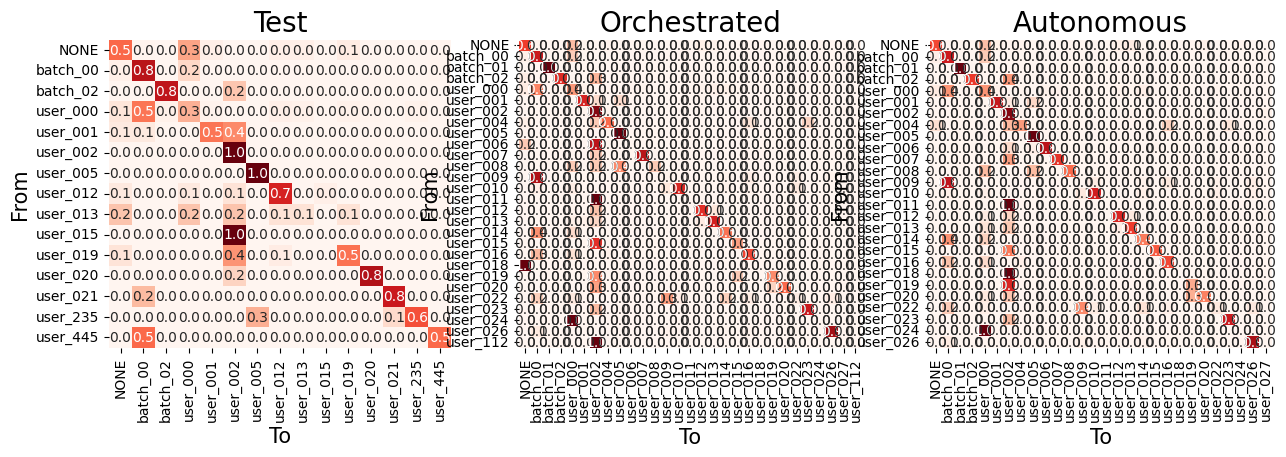

In [ ]:
# log_orch = pd.read_csv('../simulated_data/BPIChallenge2019_3WayMatchingEC_processed/autonomous/simulated_log_0.csv')
# log_auto = pd.read_csv('../simulated_data/BPIChallenge2019_3WayMatchingEC_processed/autonomous/simulated_log_1.csv')
# log_test = pd.read_csv('../simulated_data/BPIChallenge2019_3WayMatchingEC_processed/autonomous/test_preprocessed.csv')

log_orch = pd.read_csv('../simulated_data/Sepsis_ultimate_clean_for_agent/orchestrated/simulated_log_0.csv')
log_auto = pd.read_csv('../simulated_data/Sepsis_ultimate_clean_for_agent/autonomous/simulated_log_0.csv')
log_test = pd.read_csv('../simulated_data/Sepsis_ultimate_clean_for_agent/autonomous/test_preprocessed.csv')

resource_handover_heatmap_3([log_test, log_orch, log_auto])